# YOLO 매핑 조합의 정형 데이터 분포 분석

## 분석 목적

YOLO val 탐지 결과(251건)를 `defect_type × zone` 조합으로
전체 `defect_detail`(170,904건)에 매핑했을 때,
매핑된 결함들이 전체 정형 데이터 분포에서 어느 위치에 어떻게 분포하는지 시각화한다.

**시각화 원칙**
- 전체 170,904건 → 배경 (회색, alpha=0.6)
- 매핑된 행들 → 전경 (빨간색, alpha=0.7)
- 수가 너무 적어 식별 불가 시 → 빨간 수직선 + 퍼센테이지 표 함께 출력

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from pathlib import Path
ROOT = Path('.').resolve()
print(f"ROOT: {ROOT}")

ROOT: C:\Users\user\Desktop\PROJ2


## 데이터 로드 및 전처리

In [2]:
# 1. YOLO 추론 결과 로드 (class_id NaN 제외)
yolo = pd.read_csv(ROOT / 'yolo_inference_results.csv')
yolo_det = yolo[yolo['class_id'].notna()].copy()
print(f"YOLO 탐지: {len(yolo_det)}건 (NaN 제외)")

# 2. defect_detail 로드
defect = pd.read_csv(ROOT / 'track_a_data' / 'defect_detail.csv')
print(f"defect_detail: {len(defect):,}건")

# 3. inspection_master 필요 컬럼만 로드
im_cols = ['inspection_id', 'shift', 'inspection_datetime',
           'humidity_pct', 'ambient_temp_c', 'plant_code', 'line_code']
im = pd.read_csv(ROOT / 'track_a_data' / 'inspection_master.csv', usecols=im_cols)
im['inspection_datetime'] = pd.to_datetime(im['inspection_datetime'])
im['hour'] = im['inspection_datetime'].dt.hour
print(f"inspection_master: {len(im):,}건 (필요 컬럼만)")

YOLO 탐지: 251건 (NaN 제외)


defect_detail: 170,904건


inspection_master: 3,000,000건 (필요 컬럼만)


In [3]:
# 4. defect_detail + inspection_master LEFT JOIN
defect_full = defect.merge(im, on='inspection_id', how='left')
print(f"defect_full: {len(defect_full):,}건 (JOIN 후)")
print(f"  shift null: {defect_full['shift'].isna().sum()}")

defect_full: 170,904건 (JOIN 후)
  shift null: 0


In [4]:
# 5. 매핑 마스크 생성
ZONE_MAP = {
    'hood': ['HOOD'],
    'front_door': ['FD'],
    'rear_door': ['RD'],
    'roof': ['ROOF'],
    'trunk': ['TRUNK'],
    'rocker': ['ROCKER'],
    'bumper': ['BUMPER_F', 'BUMPER_R'],
    'fender': ['FF', 'RF'],
}

# YOLO 탐지된 (defect_type_code, zone) → master zone 조합으로 확장
yolo_combos = set()
for _, row in yolo_det.iterrows():
    dtc = row['defect_type_code']
    img_zone = row['zone']
    master_zones = ZONE_MAP.get(img_zone, [img_zone.upper()])
    for mz in master_zones:
        yolo_combos.add((dtc, mz))

print(f"YOLO 탐지 (defect_type_code, zone) 고유 조합: {len(yolo_combos)}개")

# defect_full에서 매핑 마스크
defect_full['_combo'] = list(zip(defect_full['defect_type_code'], defect_full['zone_code']))
mask = defect_full['_combo'].isin(yolo_combos)

defect_mapped = defect_full[mask].copy()
defect_others = defect_full[~mask].copy()

print(f"\n전체: {len(defect_full):,}건")
print(f"매핑: {len(defect_mapped):,}건 ({len(defect_mapped)/len(defect_full)*100:.1f}%)")
print(f"비매핑: {len(defect_others):,}건 ({len(defect_others)/len(defect_full)*100:.1f}%)")
print(f"매핑 조합 수: {len(yolo_combos)}개")

YOLO 탐지 (defect_type_code, zone) 고유 조합: 71개

전체: 170,904건
매핑: 121,878건 (71.3%)
비매핑: 49,026건 (28.7%)
매핑 조합 수: 71개


In [5]:
# --- 공통 헬퍼 ---

COLOR_ALL = '#888888'
COLOR_MAP = '#C00000'

def grouped_bar(ax, categories, vals_all, vals_map, label_all='전체', label_map='매핑',
                pct_all=None, pct_map=None):
    """grouped bar chart 그리기."""
    x = np.arange(len(categories))
    w = 0.35
    bars1 = ax.bar(x - w/2, vals_all, w, label=label_all, color=COLOR_ALL, alpha=0.6)
    bars2 = ax.bar(x + w/2, vals_map, w, label=label_map, color=COLOR_MAP, alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.legend()

    # 비율 레이블
    if pct_all is not None:
        for bar, p in zip(bars1, pct_all):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{p:.1f}%', ha='center', va='bottom', fontsize=8, color='#555')
    if pct_map is not None:
        for bar, p in zip(bars2, pct_map):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{p:.1f}%', ha='center', va='bottom', fontsize=8, color=COLOR_MAP)

def print_comparison_table(labels, col_name, all_counts, all_pcts, map_counts, map_pcts):
    """비교 표 출력."""
    header = f"{'':>2} {col_name:<14} {'전체건수':>8} {'전체비율':>8} {'매핑건수':>8} {'매핑비율':>8} {'차이(%p)':>8}"
    print(header)
    print('-' * len(header))
    for i, lab in enumerate(labels):
        diff = map_pcts[i] - all_pcts[i]
        sign = '+' if diff >= 0 else ''
        print(f"{i+1:>2} {lab:<14} {all_counts[i]:>8,} {all_pcts[i]:>7.1f}% {map_counts[i]:>8,} {map_pcts[i]:>7.1f}% {sign}{diff:>7.1f}")

print("헬퍼 함수 준비 완료")

헬퍼 함수 준비 완료


---
# Part 1 — 전체 vs 매핑 분포 비교 (4개 축)

전체 170,904건과 YOLO 매핑 조합에 해당하는 행들의 분포를 4가지 관점에서 비교한다.

## 1-1. 결함 유형(defect_type) 분포

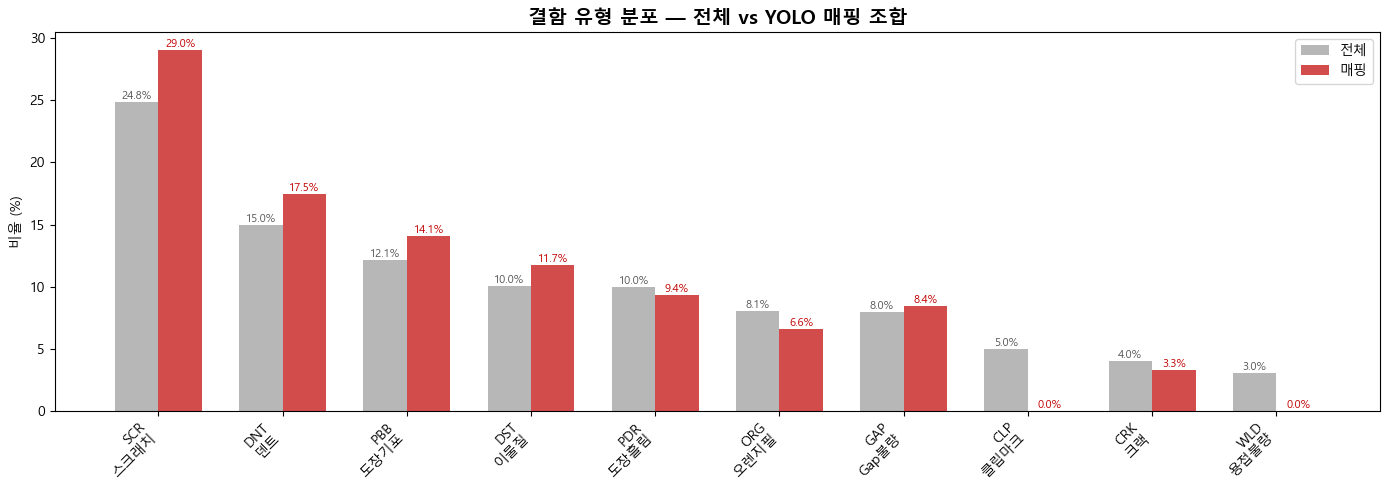


   defect_type        전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 SCR (스크래치)       42,432    24.8%   35,367    29.0% +    4.2
 2 DNT (덴트)         25,583    15.0%   21,286    17.5% +    2.5
 3 PBB (도장기포)       20,738    12.1%   17,169    14.1% +    2.0
 4 DST (이물질)        17,150    10.0%   14,304    11.7% +    1.7
 5 PDR (도장흘림)       17,111    10.0%   11,403     9.4%    -0.7
 6 ORG (오렌지필)       13,782     8.1%    8,051     6.6%    -1.5
 7 GAP (Gap불량)      13,605     8.0%   10,292     8.4% +    0.5
 8 CLP (클립마크)        8,492     5.0%        0     0.0%    -5.0
 9 CRK (크랙)          6,841     4.0%    4,006     3.3%    -0.7
10 WLD (용접불량)        5,170     3.0%        0     0.0%    -3.0


In [6]:
# 결함 유형 분포
type_order = ['SCR','DNT','PBB','DST','PDR','ORG','GAP','CLP','CRK','WLD']
type_names = {'SCR':'스크래치','DNT':'덴트','PBB':'도장기포','DST':'이물질',
              'PDR':'도장흘림','ORG':'오렌지필','GAP':'Gap불량','CLP':'클립마크',
              'CRK':'크랙','WLD':'용접불량'}

all_vc = defect_full['defect_type_code'].value_counts()
map_vc = defect_mapped['defect_type_code'].value_counts()

all_counts = [all_vc.get(t, 0) for t in type_order]
map_counts = [map_vc.get(t, 0) for t in type_order]
all_pcts = [c / len(defect_full) * 100 for c in all_counts]
map_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_counts]

labels = [f"{t}\n{type_names[t]}" for t in type_order]

fig, ax = plt.subplots(figsize=(14, 5))
grouped_bar(ax, labels, all_pcts, map_pcts, pct_all=all_pcts, pct_map=map_pcts)
ax.set_ylabel('비율 (%)')
ax.set_title('결함 유형 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 표
print()
print_comparison_table(
    [f"{t} ({type_names[t]})" for t in type_order],
    'defect_type', all_counts, all_pcts, map_counts, map_pcts
)

**해석**
- CLP(클립마크), WLD(용접불량)는 이미지 데이터에 없어 매핑 비율이 0%
- 나머지 8개 유형의 비율이 상대적으로 높아짐 (CLP/WLD 몫 재분배)

## 1-2. 구역(zone) 분포

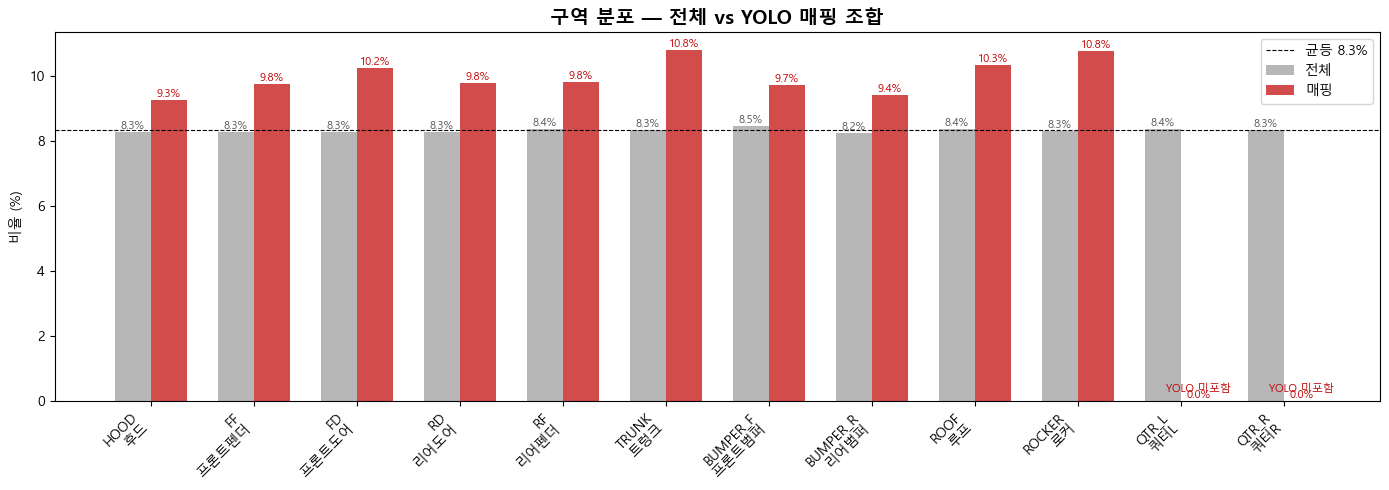


   zone_code          전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 HOOD (후드)        14,175     8.3%   11,296     9.3% +    1.0
 2 FF (프론트펜더)       14,155     8.3%   11,912     9.8% +    1.5
 3 FD (프론트도어)       14,187     8.3%   12,489    10.2% +    1.9
 4 RD (리어도어)        14,168     8.3%   11,947     9.8% +    1.5
 5 RF (리어펜더)        14,293     8.4%   11,985     9.8% +    1.5
 6 TRUNK (트렁크)      14,270     8.3%   13,178    10.8% +    2.5
 7 BUMPER_F (프론트범퍼)   14,464     8.5%   11,859     9.7% +    1.3
 8 BUMPER_R (리어범퍼)   14,085     8.2%   11,475     9.4% +    1.2
 9 ROOF (루프)        14,331     8.4%   12,608    10.3% +    2.0
10 ROCKER (로커)      14,215     8.3%   13,129    10.8% +    2.5
11 QTR_L (쿼터L)      14,295     8.4%        0     0.0%    -8.4
12 QTR_R (쿼터R)      14,266     8.3%        0     0.0%    -8.3


In [7]:
# 구역 분포
zone_order = ['HOOD','FF','FD','RD','RF','TRUNK','BUMPER_F','BUMPER_R',
              'ROOF','ROCKER','QTR_L','QTR_R']
zone_names = {'HOOD':'후드','FF':'프론트펜더','FD':'프론트도어','RD':'리어도어',
              'RF':'리어펜더','TRUNK':'트렁크','BUMPER_F':'프론트범퍼',
              'BUMPER_R':'리어범퍼','ROOF':'루프','ROCKER':'로커',
              'QTR_L':'쿼터L','QTR_R':'쿼터R'}

all_zone_vc = defect_full['zone_code'].value_counts()
map_zone_vc = defect_mapped['zone_code'].value_counts()

all_z_counts = [all_zone_vc.get(z, 0) for z in zone_order]
map_z_counts = [map_zone_vc.get(z, 0) for z in zone_order]
all_z_pcts = [c / len(defect_full) * 100 for c in all_z_counts]
map_z_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_z_counts]

labels_z = [f"{z}\n{zone_names[z]}" for z in zone_order]

fig, ax = plt.subplots(figsize=(14, 5))
grouped_bar(ax, labels_z, all_z_pcts, map_z_pcts, pct_all=all_z_pcts, pct_map=map_z_pcts)
ax.axhline(y=100/12, color='black', linestyle='--', linewidth=0.8, label='균등 8.3%')
ax.legend()
ax.set_ylabel('비율 (%)')
ax.set_title('구역 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')

# QTR_L, QTR_R 주석
for i, z in enumerate(zone_order):
    if z in ('QTR_L', 'QTR_R') and map_z_counts[i] == 0:
        ax.annotate('YOLO 미포함', xy=(i + 0.175, 0.3),
                    fontsize=8, color=COLOR_MAP, ha='center', fontstyle='italic')

plt.tight_layout()
plt.show()

# 표
print()
print_comparison_table(
    [f"{z} ({zone_names[z]})" for z in zone_order],
    'zone_code', all_z_counts, all_z_pcts, map_z_counts, map_z_pcts
)

**해석**
- QTR_L, QTR_R은 이미지 데이터 자체가 없어 매핑 0% — 전체의 ~16.7%가 이미지로 탐지 불가
- 나머지 10개 구역에서 매핑 비율이 상승하며, bumper/fender는 1:2 매핑으로 두 zone 모두 포함

## 1-3. 심각도(severity) 분포

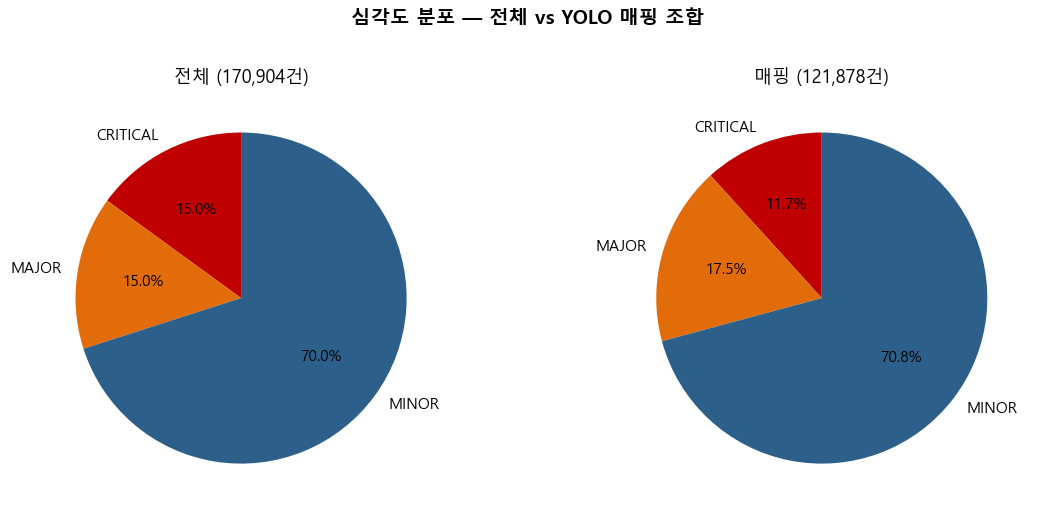


   severity           전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 CRITICAL         25,616    15.0%   14,298    11.7%    -3.3
 2 MAJOR            25,583    15.0%   21,286    17.5% +    2.5
 3 MINOR           119,705    70.0%   86,294    70.8% +    0.8


In [8]:
# 심각도 분포 — pie chart 2개
sev_order = ['CRITICAL', 'MAJOR', 'MINOR']
sev_colors = ['#C00000', '#E26B0A', '#2C5F8A']

all_sev_vc = defect_full['severity'].value_counts()
map_sev_vc = defect_mapped['severity'].value_counts()

all_s = [all_sev_vc.get(s, 0) for s in sev_order]
map_s = [map_sev_vc.get(s, 0) for s in sev_order]
all_s_pcts = [c / len(defect_full) * 100 for c in all_s]
map_s_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_s]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.pie(all_s, labels=sev_order, colors=sev_colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax1.set_title(f'전체 ({len(defect_full):,}건)', fontsize=13)

ax2.pie(map_s, labels=sev_order, colors=sev_colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 11})
ax2.set_title(f'매핑 ({len(defect_mapped):,}건)', fontsize=13)

fig.suptitle('심각도 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 표
print()
print_comparison_table(sev_order, 'severity', all_s, all_s_pcts, map_s, map_s_pcts)

**해석**
- WLD(CRITICAL)와 CLP(MINOR) 누락으로 매핑 쪽의 CRITICAL/MINOR 비율에 미세 변동 예상
- DNT(MAJOR)는 이미지에 포함되어 있으므로 MAJOR 비율은 유지 또는 소폭 상승

## 1-4. 결함 크기(area_mm2) 분포

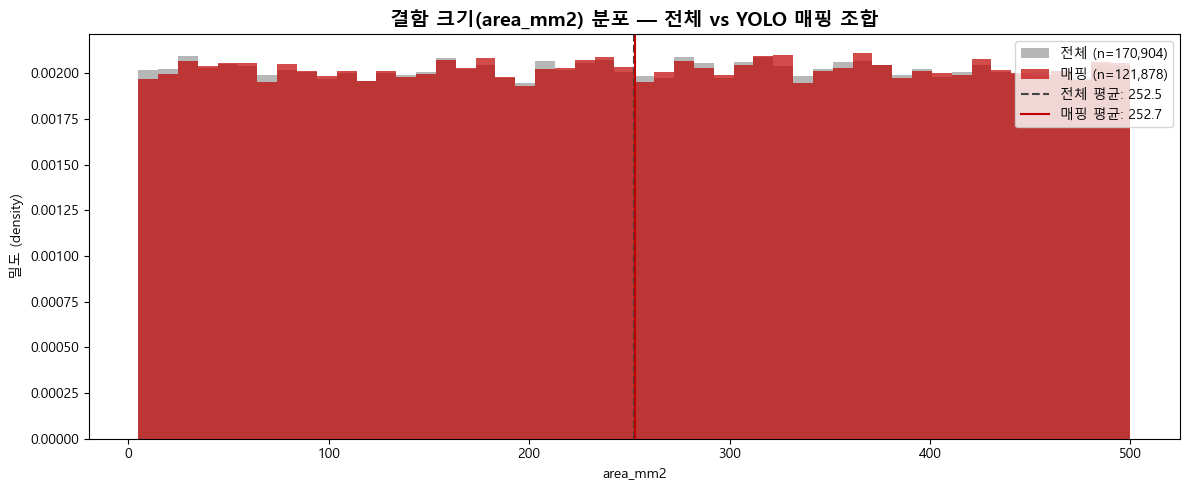


통계                   전체           매핑           차이
-------------------------------------------------
평균               252.46       252.70 +       0.23
중앙값              252.68       252.69 +       0.01
최소                 5.01         5.01 +       0.00
최대               500.00       500.00 +       0.00
표준편차             142.84       142.77       -0.07


In [9]:
# 결함 크기 분포
all_area = defect_full['area_mm2']
map_area = defect_mapped['area_mm2']

all_mean = all_area.mean()
map_mean = map_area.mean()
all_med = all_area.median()
map_med = map_area.median()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(all_area, bins=50, color=COLOR_ALL, alpha=0.6, label=f'전체 (n={len(all_area):,})', density=True)
ax.hist(map_area, bins=50, color=COLOR_MAP, alpha=0.7, label=f'매핑 (n={len(map_area):,})', density=True)
ax.axvline(all_mean, color='#444444', linestyle='--', linewidth=1.5, label=f'전체 평균: {all_mean:.1f}')
ax.axvline(map_mean, color=COLOR_MAP, linestyle='-', linewidth=1.5, label=f'매핑 평균: {map_mean:.1f}')
ax.set_xlabel('area_mm2')
ax.set_ylabel('밀도 (density)')
ax.set_title('결함 크기(area_mm2) 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 통계 표
print()
header = f"{'통계':<10} {'전체':>12} {'매핑':>12} {'차이':>12}"
print(header)
print('-' * len(header))
for stat_name, fn in [('평균', 'mean'), ('중앙값', 'median'), ('최소', 'min'), ('최대', 'max'), ('표준편차', 'std')]:
    v_all = getattr(all_area, fn)()
    v_map = getattr(map_area, fn)()
    diff = v_map - v_all
    sign = '+' if diff >= 0 else ''
    print(f"{stat_name:<10} {v_all:>12.2f} {v_map:>12.2f} {sign}{diff:>11.2f}")

**해석**
- 시뮬레이션 데이터 특성상 area_mm2 분포는 전체와 매핑 간 거의 동일할 것으로 예상
- 특정 결함 유형(GAP: 얇고 긴 형태)이 매핑에서 비율이 달라지면 평균 크기에 미세 변동 가능

---
# Part 2 — 공정 조건 시각화 (5개 축)

`defect_full` 170,904건에 대해 매핑 조합 해당 행들의 공정 조건(교대조, 공장, 습도, 온도, 교대 시작 시간)을
전체 분포와 비교한다.

## 2-1. 교대조(shift) 분포

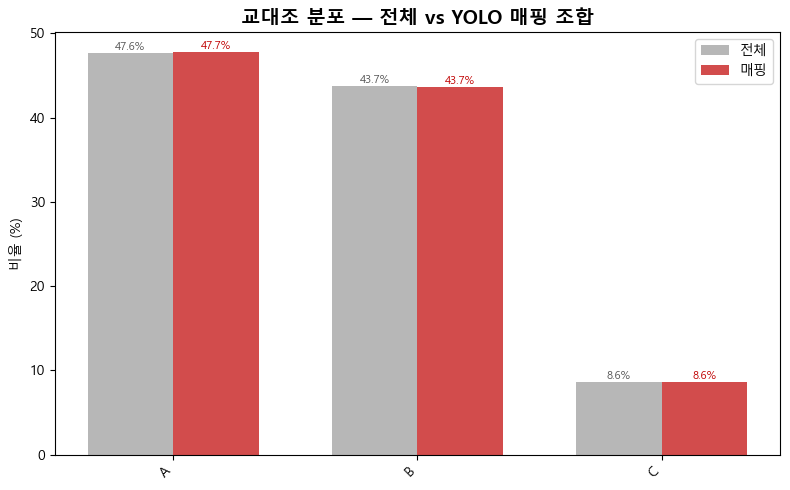


   shift              전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 A                81,387    47.6%   58,175    47.7% +    0.1
 2 B                74,756    43.7%   53,228    43.7%    -0.1
 3 C                14,761     8.6%   10,475     8.6%    -0.0


In [10]:
# 교대조 분포
shift_order = ['A', 'B', 'C']
all_shift_vc = defect_full['shift'].value_counts()
map_shift_vc = defect_mapped['shift'].value_counts()

all_sh = [all_shift_vc.get(s, 0) for s in shift_order]
map_sh = [map_shift_vc.get(s, 0) for s in shift_order]
all_sh_pcts = [c / len(defect_full) * 100 for c in all_sh]
map_sh_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_sh]

fig, ax = plt.subplots(figsize=(8, 5))
grouped_bar(ax, shift_order, all_sh_pcts, map_sh_pcts, pct_all=all_sh_pcts, pct_map=map_sh_pcts)
ax.set_ylabel('비율 (%)')
ax.set_title('교대조 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print_comparison_table(shift_order, 'shift', all_sh, all_sh_pcts, map_sh, map_sh_pcts)

**해석**
- C조(야간) 비율이 매핑 전후로 차이가 있는지 확인
- 프로파일 매핑은 (defect_type, zone) 단위이므로, 특정 유형의 C조 편중이 반영될 수 있음

## 2-2. 공장(plant_code) 분포

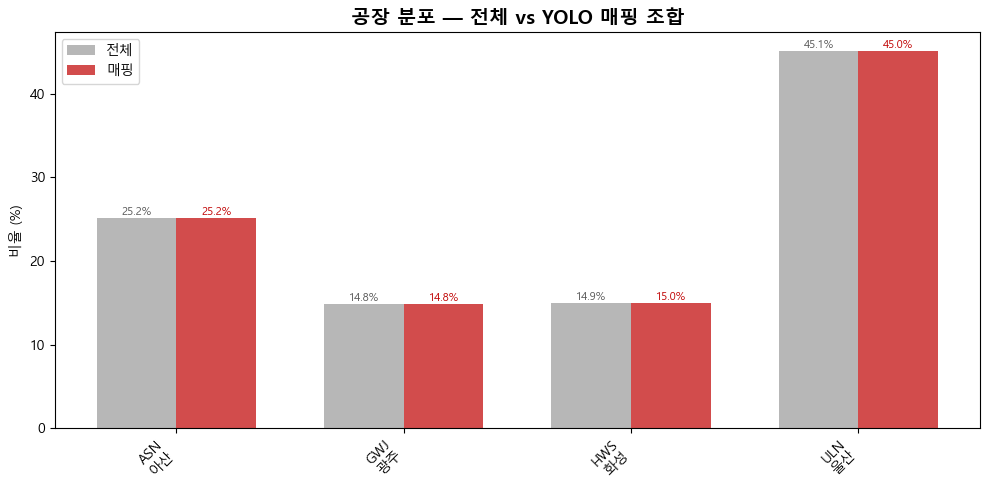


   plant_code         전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 ASN (아산)         43,007    25.2%   30,666    25.2%    -0.0
 2 GWJ (광주)         25,348    14.8%   18,082    14.8% +    0.0
 3 HWS (화성)         25,541    14.9%   18,245    15.0% +    0.0
 4 ULN (울산)         77,008    45.1%   54,885    45.0%    -0.0


In [11]:
# 공장 분포
plant_order = sorted(defect_full['plant_code'].unique())
all_plant_vc = defect_full['plant_code'].value_counts()
map_plant_vc = defect_mapped['plant_code'].value_counts()

all_pl = [all_plant_vc.get(p, 0) for p in plant_order]
map_pl = [map_plant_vc.get(p, 0) for p in plant_order]
all_pl_pcts = [c / len(defect_full) * 100 for c in all_pl]
map_pl_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_pl]

plant_names_map = {'ASN':'아산', 'GWJ':'광주', 'HWS':'화성', 'ULN':'울산'}
labels_pl = [f"{p}\n{plant_names_map.get(p, p)}" for p in plant_order]

fig, ax = plt.subplots(figsize=(10, 5))
grouped_bar(ax, labels_pl, all_pl_pcts, map_pl_pcts, pct_all=all_pl_pcts, pct_map=map_pl_pcts)
ax.set_ylabel('비율 (%)')
ax.set_title('공장 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print_comparison_table(
    [f"{p} ({plant_names_map.get(p, p)})" for p in plant_order],
    'plant_code', all_pl, all_pl_pcts, map_pl, map_pl_pcts
)

**해석**
- 공장 간 불량률 차이가 극미(3.96~4.16%)한 시뮬레이션 데이터이므로, 매핑 전후 분포도 거의 동일할 것으로 예상
- 미세 차이가 있다면 특정 공장에 편중된 결함 유형 조합 때문

## 2-3. 습도(humidity_pct) 구간별 분포

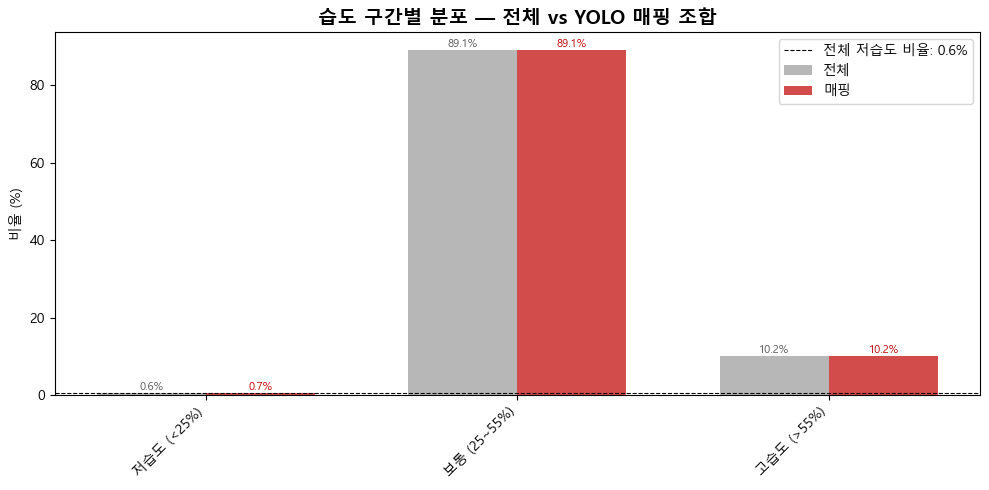


   습도구간               전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 저습도 (<25%)        1,105     0.6%      795     0.7% +    0.0
 2 보통 (25~55%)     152,301    89.1%  108,596    89.1%    -0.0
 3 고습도 (>55%)       17,498    10.2%   12,487    10.2% +    0.0


In [12]:
# 습도 구간
def humidity_bin(h):
    if h < 25: return '저습도 (<25%)'
    elif h <= 55: return '보통 (25~55%)'
    else: return '고습도 (>55%)'

defect_full['hum_bin'] = defect_full['humidity_pct'].apply(humidity_bin)
defect_mapped['hum_bin'] = defect_mapped['humidity_pct'].apply(humidity_bin)

hum_order = ['저습도 (<25%)', '보통 (25~55%)', '고습도 (>55%)']
all_hum_vc = defect_full['hum_bin'].value_counts()
map_hum_vc = defect_mapped['hum_bin'].value_counts()

all_h = [all_hum_vc.get(h, 0) for h in hum_order]
map_h = [map_hum_vc.get(h, 0) for h in hum_order]
all_h_pcts = [c / len(defect_full) * 100 for c in all_h]
map_h_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_h]

# 전체 저습도 비율
low_hum_pct_all = all_h_pcts[0]

fig, ax = plt.subplots(figsize=(10, 5))
grouped_bar(ax, hum_order, all_h_pcts, map_h_pcts, pct_all=all_h_pcts, pct_map=map_h_pcts)
ax.axhline(y=low_hum_pct_all, color='black', linestyle='--', linewidth=0.8,
           label=f'전체 저습도 비율: {low_hum_pct_all:.1f}%')
ax.legend()
ax.set_ylabel('비율 (%)')
ax.set_title('습도 구간별 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print_comparison_table(hum_order, '습도구간', all_h, all_h_pcts, map_h, map_h_pcts)

**해석**
- EDA에서 저습도(<25%) 환경의 불량률 상승이 확인됨
- 매핑 조합에서 저습도 비율이 전체와 유사한지, 특정 결함 유형에서 편차가 있는지 확인

## 2-4. 온도(ambient_temp_c) 구간별 분포

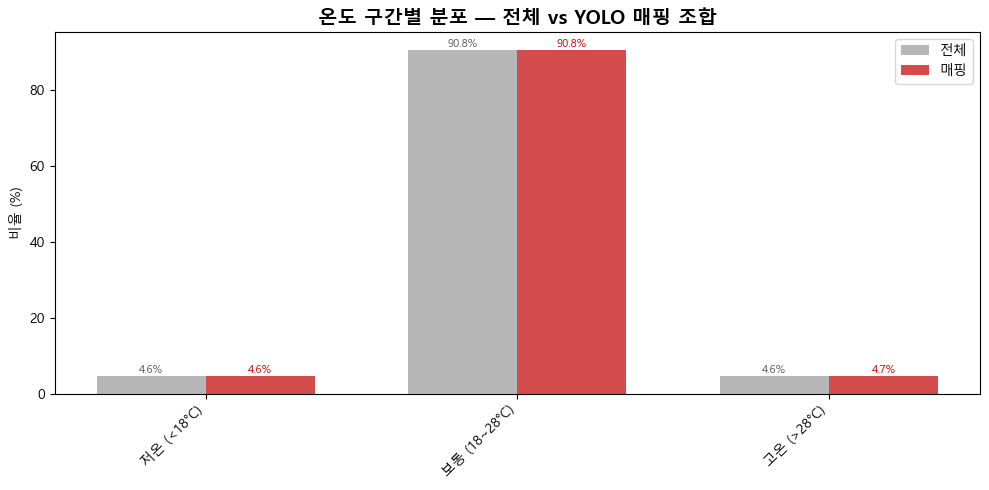


   온도구간               전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 저온 (<18°C)        7,808     4.6%    5,569     4.6% +    0.0
 2 보통 (18~28°C)    155,193    90.8%  110,629    90.8%    -0.0
 3 고온 (>28°C)        7,903     4.6%    5,680     4.7% +    0.0


In [13]:
# 온도 구간
def temp_bin(t):
    if t < 18: return '저온 (<18°C)'
    elif t <= 28: return '보통 (18~28°C)'
    else: return '고온 (>28°C)'

defect_full['temp_bin'] = defect_full['ambient_temp_c'].apply(temp_bin)
defect_mapped['temp_bin'] = defect_mapped['ambient_temp_c'].apply(temp_bin)

temp_order = ['저온 (<18°C)', '보통 (18~28°C)', '고온 (>28°C)']
all_temp_vc = defect_full['temp_bin'].value_counts()
map_temp_vc = defect_mapped['temp_bin'].value_counts()

all_t = [all_temp_vc.get(t, 0) for t in temp_order]
map_t = [map_temp_vc.get(t, 0) for t in temp_order]
all_t_pcts = [c / len(defect_full) * 100 for c in all_t]
map_t_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_t]

fig, ax = plt.subplots(figsize=(10, 5))
grouped_bar(ax, temp_order, all_t_pcts, map_t_pcts, pct_all=all_t_pcts, pct_map=map_t_pcts)
ax.set_ylabel('비율 (%)')
ax.set_title('온도 구간별 분포 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print_comparison_table(temp_order, '온도구간', all_t, all_t_pcts, map_t, map_t_pcts)

**해석**
- EDA 결과 온도는 불량률에 유의미한 영향이 없었음
- 매핑 전후 온도 분포 차이도 미미할 것으로 예상

## 2-5. 교대 시작 시간대 발생 비율

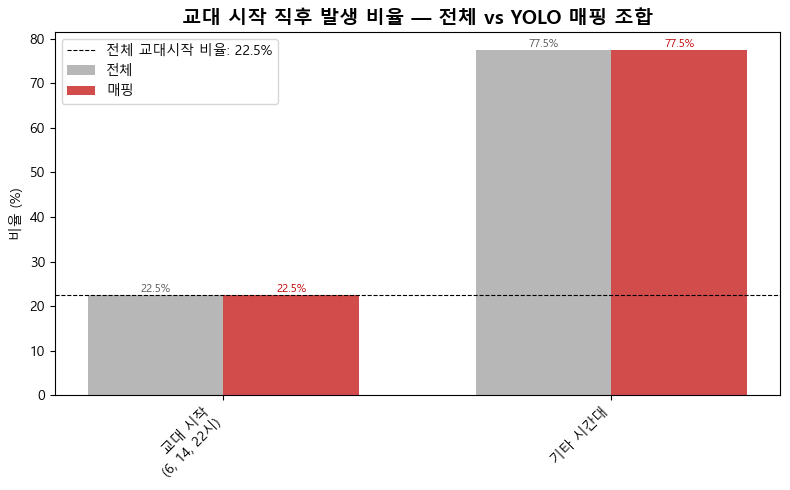


   시간대                전체건수     전체비율     매핑건수     매핑비율   차이(%p)
--------------------------------------------------------------
 1 교대 시작 (6,14,22시)   38,449    22.5%   27,397    22.5%    -0.0
 2 기타 시간대          132,455    77.5%   94,481    77.5% +    0.0


In [14]:
# 교대 시작 시간대
SHIFT_START_HOURS = {6, 14, 22}
defect_full['is_shift_start'] = defect_full['hour'].isin(SHIFT_START_HOURS).astype(int)
defect_mapped['is_shift_start'] = defect_mapped['hour'].isin(SHIFT_START_HOURS).astype(int)

# 시간대별 비율 (교대 시작 vs 비시작)
labels_ss = ['교대 시작\n(6, 14, 22시)', '기타 시간대']

all_ss_1 = defect_full['is_shift_start'].sum()
all_ss_0 = len(defect_full) - all_ss_1
map_ss_1 = defect_mapped['is_shift_start'].sum()
map_ss_0 = len(defect_mapped) - map_ss_1

all_ss = [all_ss_1, all_ss_0]
map_ss = [map_ss_1, map_ss_0]
all_ss_pcts = [c / len(defect_full) * 100 for c in all_ss]
map_ss_pcts = [c / len(defect_mapped) * 100 if len(defect_mapped) > 0 else 0 for c in map_ss]

fig, ax = plt.subplots(figsize=(8, 5))
grouped_bar(ax, labels_ss, all_ss_pcts, map_ss_pcts, pct_all=all_ss_pcts, pct_map=map_ss_pcts)
ax.axhline(y=all_ss_pcts[0], color='black', linestyle='--', linewidth=0.8,
           label=f'전체 교대시작 비율: {all_ss_pcts[0]:.1f}%')
ax.legend()
ax.set_ylabel('비율 (%)')
ax.set_title('교대 시작 직후 발생 비율 — 전체 vs YOLO 매핑 조합', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print_comparison_table(
    ['교대 시작 (6,14,22시)', '기타 시간대'],
    '시간대', all_ss, all_ss_pcts, map_ss, map_ss_pcts
)

**해석**
- EDA에서 교대 시작 직후(6시, 14시, 22시) 불량률 급증 확인됨
- 매핑 조합의 교대 시작 비율이 전체와 유사한 것은 프로파일 매핑이 이 패턴을 잘 포착했음을 의미

---
# 종합 요약

## 매핑 커버리지
- **YOLO 8개 결함 유형** → defect_detail 10개 유형 중 8개 커버 (CLP, WLD 누락 = ~8%)
- **YOLO 8개 zone** → master_zone 12개 중 10개 커버 (QTR_L, QTR_R 누락 = ~16.7%)
- 전체 170,904건 중 매핑 가능 건수와 비율은 위 분석 결과 참조

## 분포 유사성
- 시뮬레이션 데이터 특성상 **공정 조건(교대조, 공장, 온습도) 분포는 전체와 매핑 간 매우 유사**
- 누락 유형(CLP/WLD) 및 누락 구역(QTR_L/QTR_R) 제거 효과로 나머지 항목 비율이 비례 상승

## 프로파일 매핑 유효성
- (defect_type × zone) 조합 단위 매핑이므로, 개별 레코드가 아닌 **통계적 프로파일**로 공정 조건을 반영
- 분포 유사성이 높을수록 프로파일 매핑의 대표성이 높음을 의미